In [1]:
import numpy as np
from torchvision import datasets, transforms
import matplotlib.pyplot as plt

In [6]:
transform = transforms.ToTensor()
train_dataset = datasets.EMNIST(root='./data', split='balanced', train=True, download=False, transform=transform)
test_dataset = datasets.EMNIST(root='./data', split='balanced', train=False, download=False, transform=transform)

X_train = np.array([img.flatten().numpy() for img, _ in train_dataset])
y_train = np.array([label for _, label in train_dataset])
X_test = np.array([img.flatten().numpy() for img, _ in test_dataset])
y_test = np.array([label for _, label in test_dataset])

In [7]:
print(X_train.shape)
print(y_train.shape)
print(X_test.shape)
print(y_test.shape)

(112800, 784)
(112800,)
(18800, 784)
(18800,)


In [8]:
X_train

array([[0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       ...,
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.]], shape=(112800, 784), dtype=float32)

In [9]:
# (n_features, m_examples)

X_train = X_train.T
X_test = X_test.T

In [10]:
print(X_train.shape)
print(X_test.shape)

(784, 112800)
(784, 18800)


In [11]:
y_train

array([45, 36, 43, ..., 23, 31,  8], shape=(112800,))

In [12]:
num_classes = len(np.unique(y_train))
num_classes

47

In [13]:
# (n_classes, m_examples)

Y_train = np.eye(num_classes)[y_train].T
Y_test = np.eye(num_classes)[y_test].T

In [14]:
print(Y_train.shape)
print(Y_test.shape)

(47, 112800)
(47, 18800)


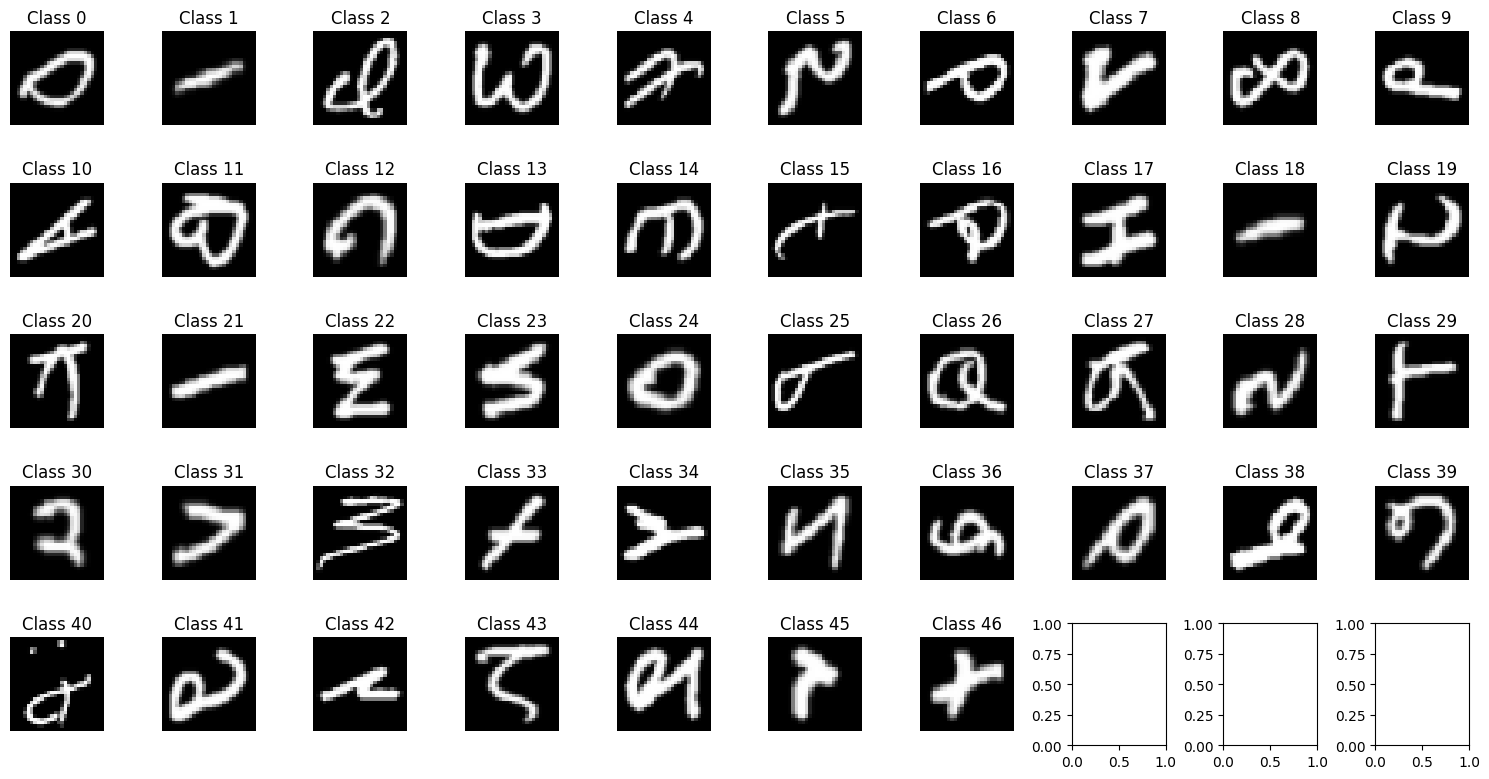

In [16]:
fig, axes = plt.subplots(5, 10, figsize=(15, 8))
axes = axes.flatten()

for class_idx in range(num_classes):
    sample_idx = np.where(y_train == class_idx)[0][0]
    
    image = X_train[:, sample_idx].reshape(28, 28)
    
    axes[class_idx].imshow(image, cmap='gray')
    axes[class_idx].set_title(f'Class {class_idx}')
    axes[class_idx].axis('off')

plt.tight_layout()
plt.show()